In [ ]:
%cd ..

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from optimizers import SOAP

In [3]:
import guides
import models
import samplers
import trainers
import utils

import torch
import numpy as np

In [4]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 10) * k_0

# normalized simulation lengths
substrate_length = (6 * lambd) * k_0
core_length = (2 * lambd) * k_0
cladding_length = (6 * lambd) * k_0

# refractive indices
n_substrate = 1.44
n_core = 1.55
n_cladding = 1.44

In [5]:
study = 'TE'
field_type = 'E'

In [6]:
RIs = [n_substrate, n_core, n_cladding]
lengths = [substrate_length, core_length, cladding_length]

In [7]:
reference_device = guides.SlabWaveguide(RIs, lambd, lengths, study=study, field_type=field_type)

In [8]:
device = torch.device('cpu')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 1

In [9]:
base_model = models.vanilla_network(1, 64, num_modes, 2, 'Siren')
# base_model.apply(models.default_init)
optimzer = SOAP(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 1500], gamma=0.1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4353


In [10]:
guide = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, False)

In [11]:
train_agent = trainers.Trainer(dtype, guide, device, [samplers.uniform_grid], optimzer, scheduler, dx)


num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00249, loss2 is 0.04068, loss3 is 1.19312, loss4 is 0.0, loss5 is 0.04426, loss6 is 0.0


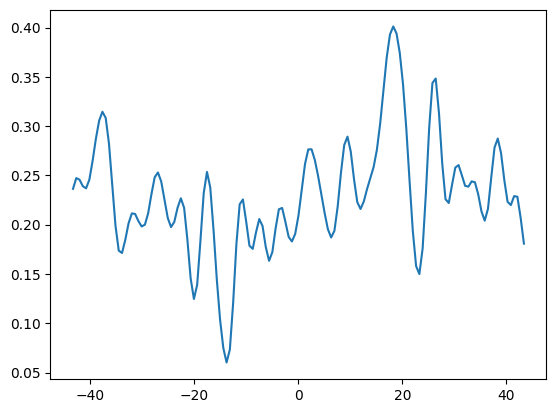

iteration 1001 loss1 is 8e-05, loss2 is 0.00064, loss3 is 0.5364, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.0


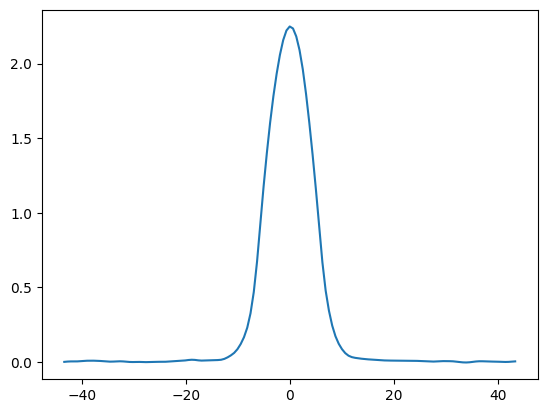

iteration 2001 loss1 is 4e-05, loss2 is 0.0005, loss3 is 0.53608, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


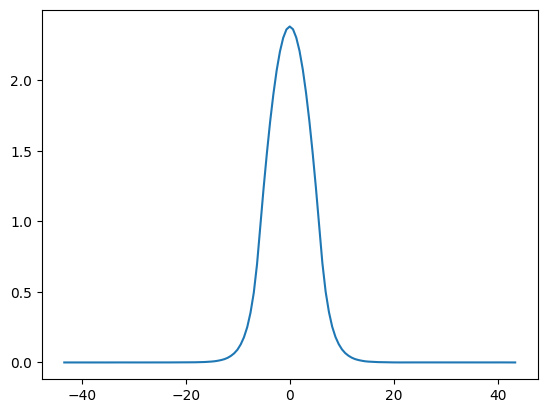

In [12]:
loss_history, rayleigh_history, mode_errors_list, u_pred = train_agent.train(2001, num_modes, weights=[10, 1, 1, 1, 1, 1], verbose=1, sample_new=False, plot_solution=True)

# FD Performance

In [13]:
fd_device = guides.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u))

[3.2863834762109656]

# NN Performance

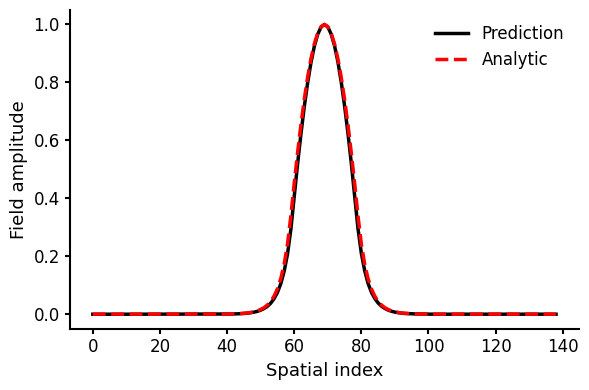

[3.915457408194239]

In [15]:
# augmented_x = torch.cat((torch.from_numpy(evaluation_points).reshape(-1, 1), 1/device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)
base_x = torch.from_numpy(x).reshape(-1, 1).to(device)
predictions = torch.cat(([guide.underlying_model(base_x) for i in range(num_modes)]), dim=1)
predictions /= torch.max(abs(predictions), dim=0, keepdim=True)[0]
prediction_normed = predictions.detach().cpu() / torch.max(torch.abs(predictions.detach().cpu()), dim=0, keepdims=True)[0]
utils.compare_against_analytic(reference_device, x, prediction_normed.detach().cpu(), plot=True)

In [16]:
x_tensor = torch.from_numpy(x)
x_tensor.requires_grad = True
x_augmented = torch.cat((x_tensor.reshape(-1, 1), 1/guide.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1)
base_x = torch.from_numpy(x).reshape(-1, 1).to(device)
base_x.requires_grad = True

NN_EI = [guide.calculate_eigen_value(base_x.to(device), 0).item()**(1/2) for i in range(num_modes)]
# NN_EI = [mode_models[i].calculate_eigen_value(x_augmented.to(memory_type), 0).item()**(1/2) for i in range(num_modes)]

_**(1/2), '\n', reference_device.evaluate_analytical(x, 3)[1], '\n', NN_EI

(array([1.53679813]),
 '\n',
 array([1.53770616, 1.50182214, 1.44996588]),
 '\n',
 [1.5367496947272694])

# Multiple Modes
## Parallel mode solving

number of trainable parameters 33667
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00931, loss2 is 0.01858, loss3 is 1.77384, loss4 is 2.9836, loss5 is 0.2156, loss6 is 0.0


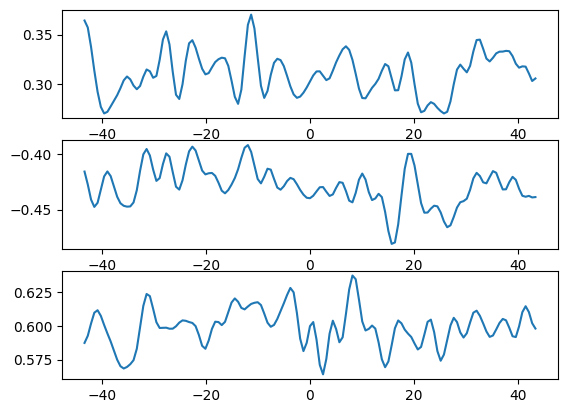

iteration 1001 loss1 is 0.00737, loss2 is 0.00149, loss3 is 1.22093, loss4 is 0.00698, loss5 is 0.00023, loss6 is 0.0


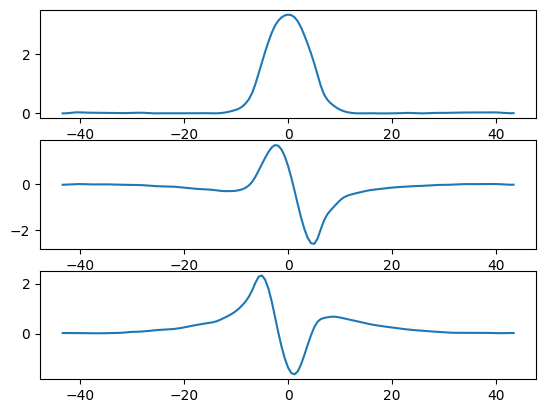

iteration 2001 loss1 is 0.00623, loss2 is 0.00153, loss3 is 1.20813, loss4 is 0.00526, loss5 is 0.00014, loss6 is 0.0


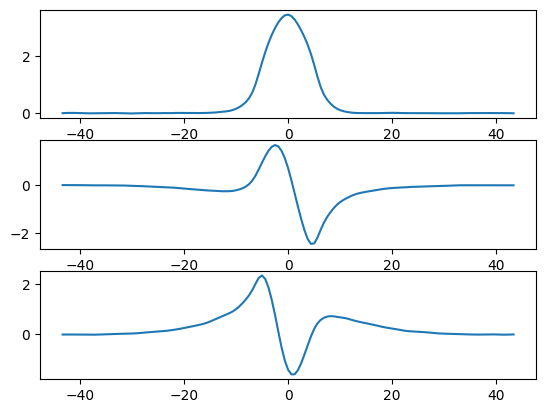

iteration 3001 loss1 is 0.00723, loss2 is 0.00161, loss3 is 1.23022, loss4 is 0.00608, loss5 is 0.0001, loss6 is 0.0


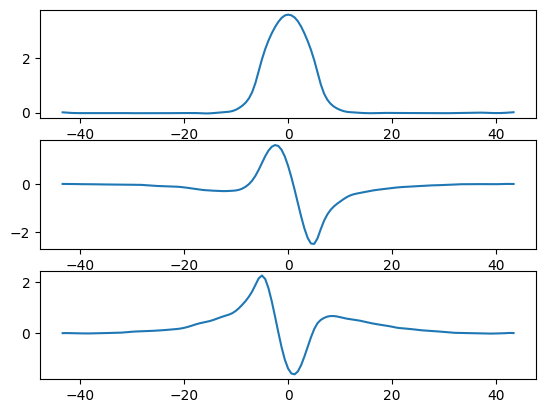

iteration 4001 loss1 is 0.00623, loss2 is 0.00136, loss3 is 1.21563, loss4 is 0.00327, loss5 is 0.00014, loss6 is 0.0


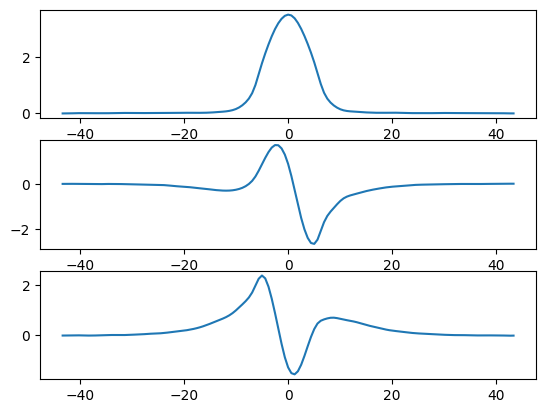

iteration 5001 loss1 is 0.00616, loss2 is 0.00137, loss3 is 1.2159, loss4 is 0.00756, loss5 is 0.00066, loss6 is 0.0


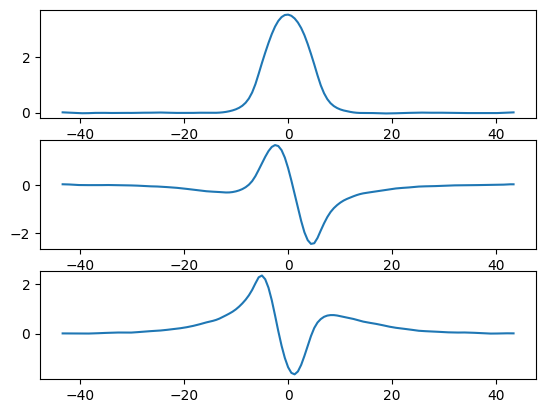

iteration 6001 loss1 is 0.00479, loss2 is 0.00139, loss3 is 1.20903, loss4 is 0.0022, loss5 is 2e-05, loss6 is 0.0


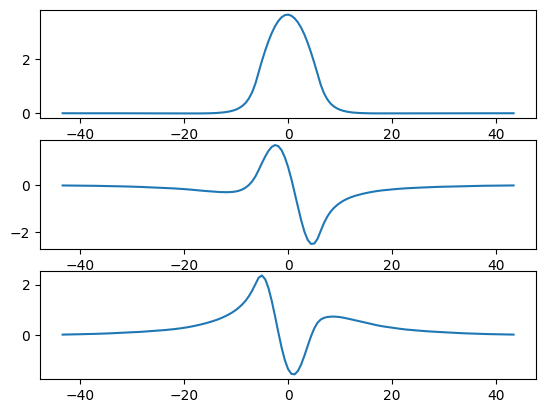

iteration 7001 loss1 is 0.0047, loss2 is 0.00132, loss3 is 1.20924, loss4 is 0.00364, loss5 is 4e-05, loss6 is 0.0


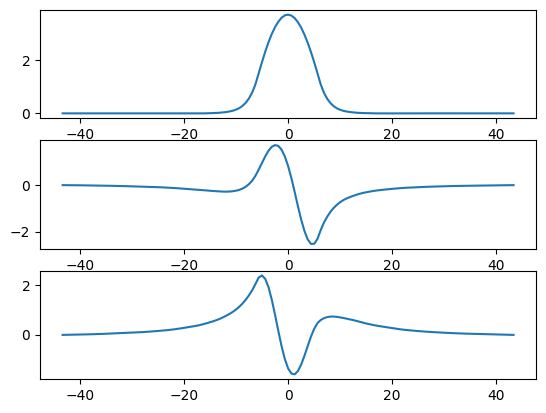

iteration 8001 loss1 is 0.00545, loss2 is 0.00134, loss3 is 1.22473, loss4 is 0.00398, loss5 is 1e-05, loss6 is 0.0


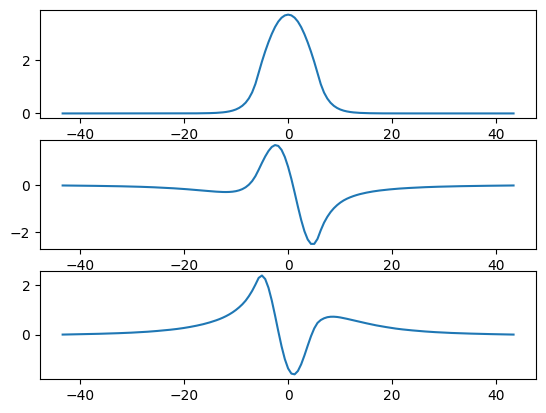

iteration 9001 loss1 is 0.00428, loss2 is 0.00132, loss3 is 1.2121, loss4 is 0.00617, loss5 is 0.0, loss6 is 0.0


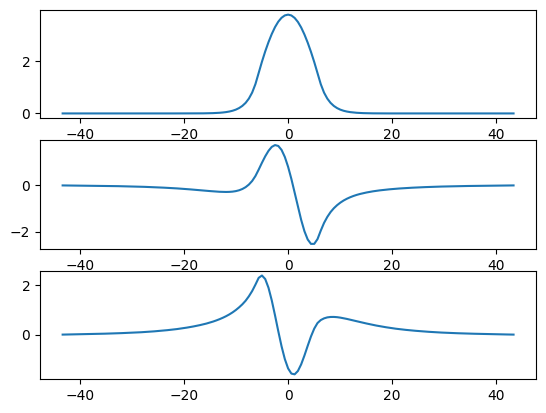

iteration 10001 loss1 is 0.00514, loss2 is 0.00133, loss3 is 1.20201, loss4 is 0.00492, loss5 is 1e-05, loss6 is 0.0


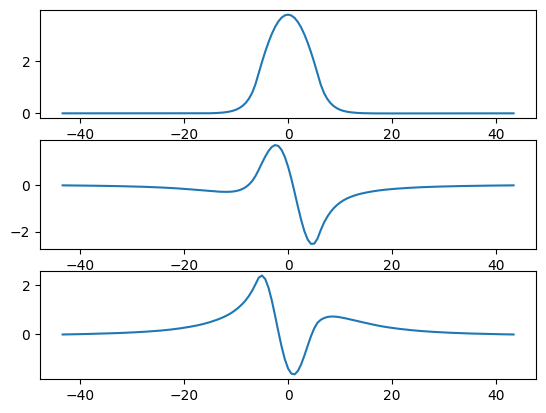

In [17]:
torch.manual_seed(42)
base_model = models.vanilla_network(1, 128, 3, 3, 'Siren')
optimzer = SOAP(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[5000, 7500], gamma=0.1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))
guide = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, False)
train_agent = trainers.Trainer(dtype, guide, device, [samplers.uniform_grid], optimzer, scheduler, dx)
loss_history, rayleigh_history, mode_errors_list, u_iter = train_agent.train(10001, 3, weights=[1, 2, 1, 1, 1, 1], verbose=1, sample_new=False, plot_solution=True, u_ref=None)

## Sequential mode solving

number of trainable parameters 4353
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00249, loss2 is 0.04068, loss3 is 1.19312, loss4 is 0.0, loss5 is 0.04426, loss6 is 0.0


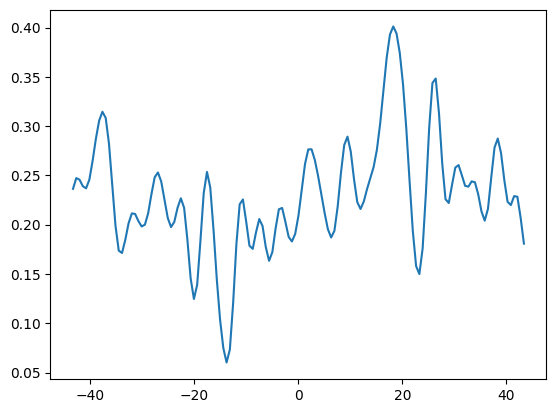

iteration 1001 loss1 is 0.0004, loss2 is 0.0001, loss3 is 0.53652, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


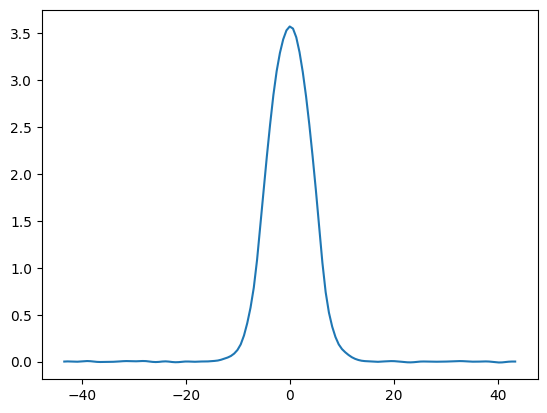

iteration 2001 loss1 is 0.00034, loss2 is 0.00012, loss3 is 0.53651, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.0


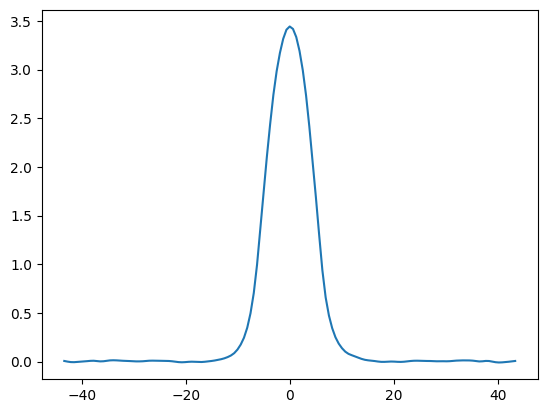

iteration 3001 loss1 is 0.0002, loss2 is 8e-05, loss3 is 0.53687, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


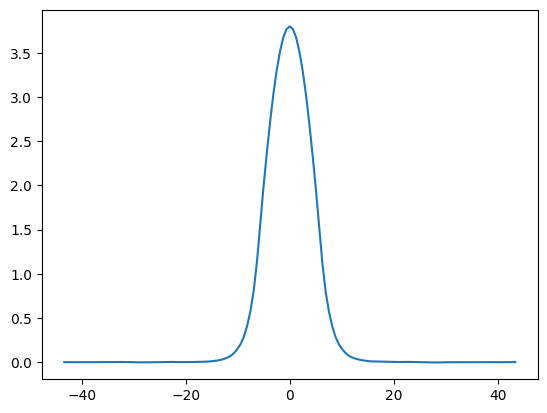

iteration 4001 loss1 is 0.00025, loss2 is 8e-05, loss3 is 0.5359, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


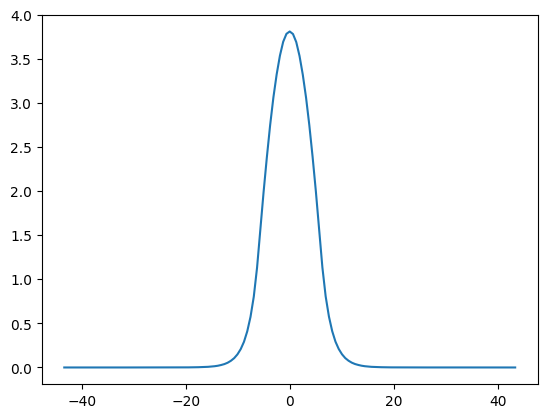

iteration 5001 loss1 is 9e-05, loss2 is 8e-05, loss3 is 0.53687, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


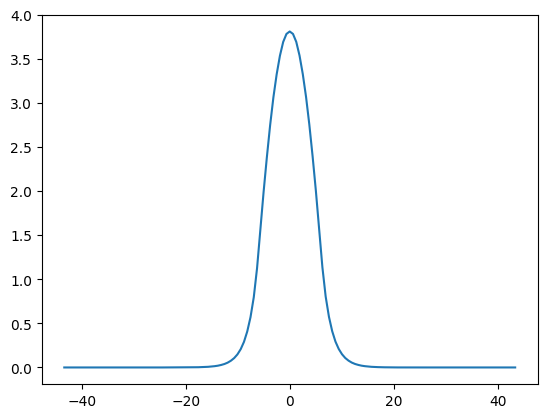

number of trainable parameters 4353
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.0165, loss2 is 0.00011, loss3 is 0.97391, loss4 is 0.16254, loss5 is 0.98172, loss6 is 0.0


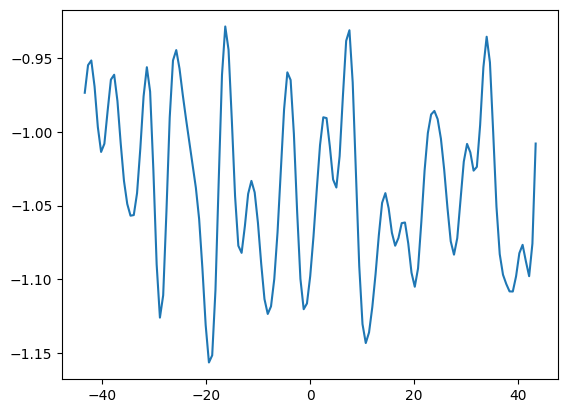

iteration 1001 loss1 is 0.00096, loss2 is 0.00025, loss3 is 0.68589, loss4 is 0.00016, loss5 is 2e-05, loss6 is 0.0


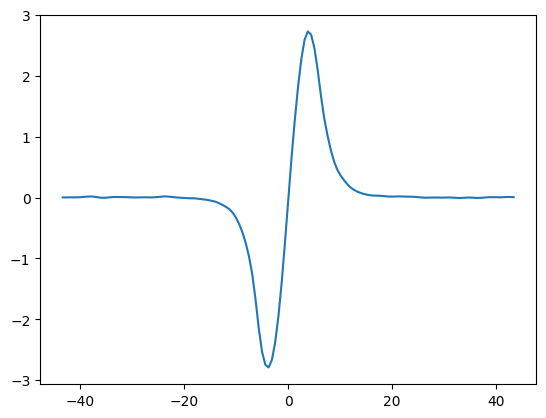

iteration 2001 loss1 is 0.00074, loss2 is 0.00033, loss3 is 0.67311, loss4 is 7e-05, loss5 is 0.0001, loss6 is 0.0


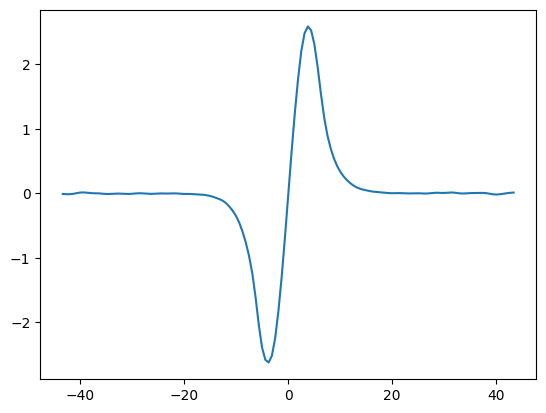

iteration 3001 loss1 is 0.00057, loss2 is 0.00017, loss3 is 0.68748, loss4 is 0.00035, loss5 is 0.0, loss6 is 0.0


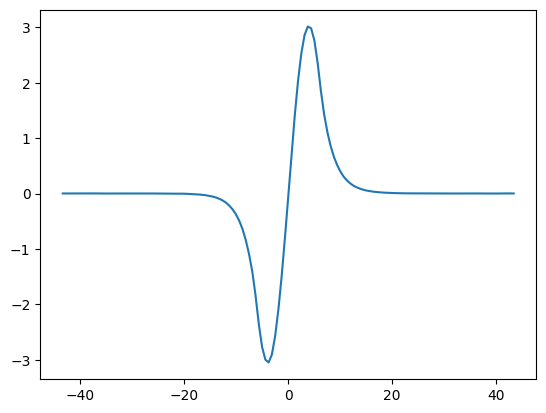

iteration 4001 loss1 is 0.00016, loss2 is 0.00015, loss3 is 0.67932, loss4 is 7e-05, loss5 is 0.0, loss6 is 0.0


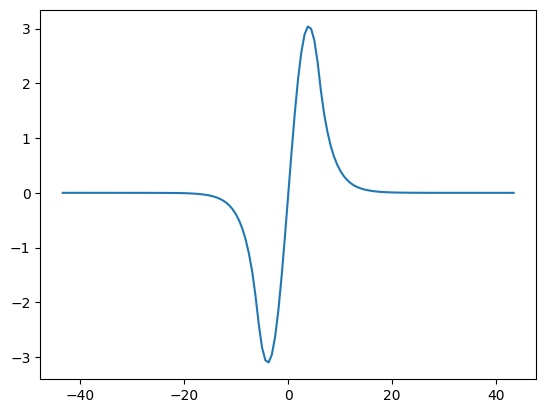

iteration 5001 loss1 is 0.00063, loss2 is 0.00016, loss3 is 0.67991, loss4 is 0.00024, loss5 is 0.0, loss6 is 0.0


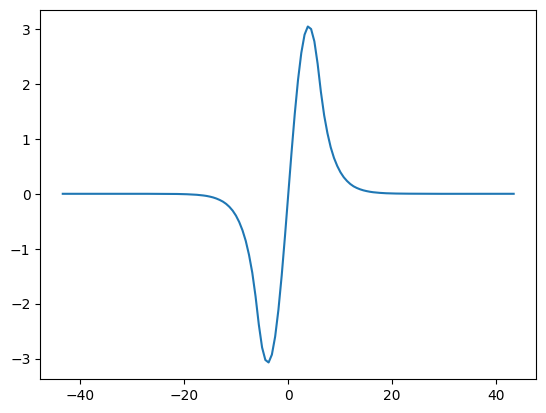

number of trainable parameters 4353
num PDE samples 139
num rayleigh samples 139
iteration 1 loss1 is 0.00419, loss2 is 0.02539, loss3 is 1.06289, loss4 is 0.17089, loss5 is 0.07797, loss6 is 0.0


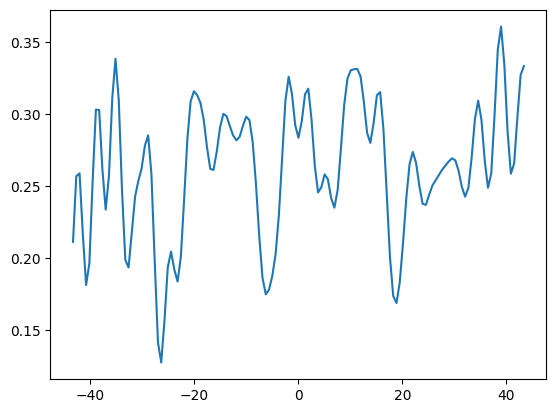

iteration 1001 loss1 is 0.00147, loss2 is 0.0003, loss3 is 1.13629, loss4 is 0.00013, loss5 is 1e-05, loss6 is 0.0


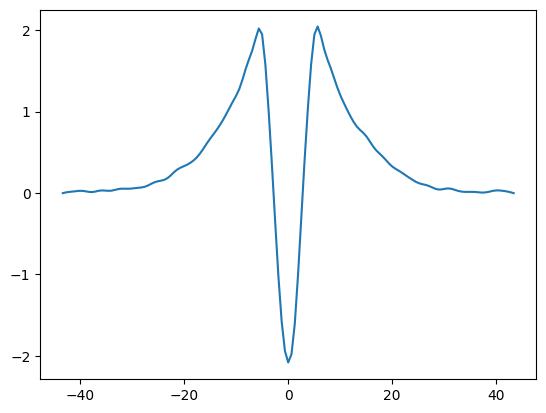

iteration 2001 loss1 is 0.00124, loss2 is 0.00031, loss3 is 1.13396, loss4 is 2e-05, loss5 is 2e-05, loss6 is 0.0


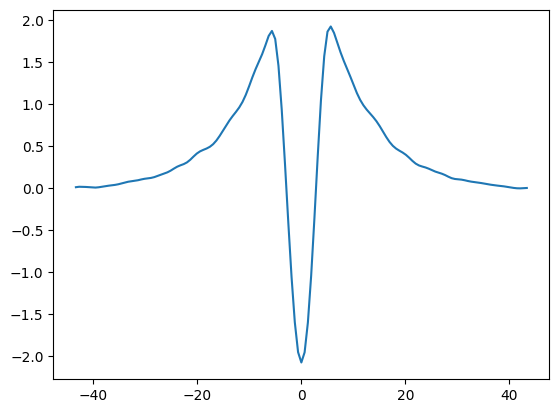

iteration 3001 loss1 is 0.00136, loss2 is 0.00023, loss3 is 1.17268, loss4 is 0.00087, loss5 is 0.0, loss6 is 0.0


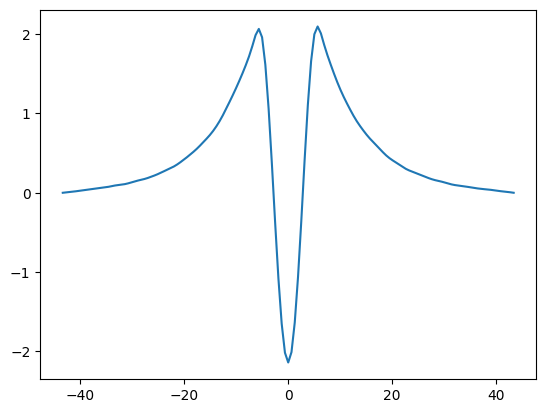

iteration 4001 loss1 is 0.0007, loss2 is 0.00021, loss3 is 1.15772, loss4 is 5e-05, loss5 is 0.0, loss6 is 0.0


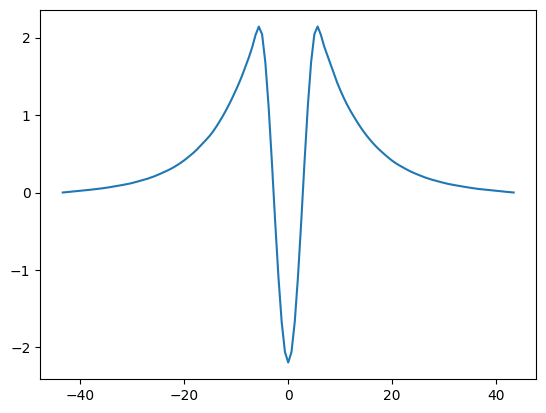

iteration 5001 loss1 is 0.00068, loss2 is 0.00021, loss3 is 1.11306, loss4 is 0.00043, loss5 is 0.0, loss6 is 0.0


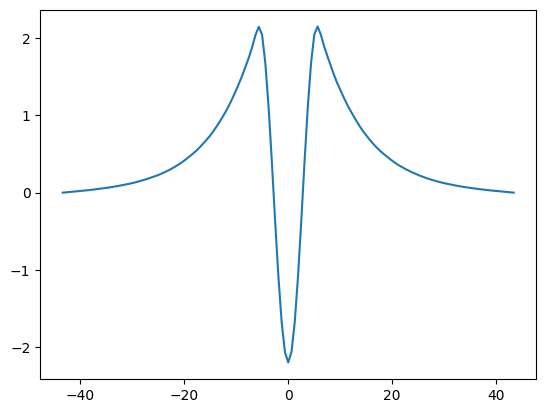

In [18]:
torch.manual_seed(42)
u_ref = []
model_networks = []
for i in range(num_modes):
    base_model = models.vanilla_network(1, 64, 1, 2, 'Siren')
    optimzer = SOAP(base_model.parameters(), lr=1e-2, weight_decay=0)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[2500, 3750], gamma=0.1)
    print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))
    guide = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, False)
    train_agent = trainers.Trainer(dtype, guide, device, [samplers.uniform_grid], optimzer, scheduler, dx)
    loss_history, rayleigh_history, mode_errors_list, u_iter = train_agent.train(5001, 1, weights=[1, 2, 1/(i+1), 1, 1, 1], verbose=1, sample_new=False, plot_solution=True, u_ref=u_ref)
    model_networks.append(base_model)
    u_ref.append(u_iter)

In [19]:
fd_device = guides.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u))

[3.286383476210978]

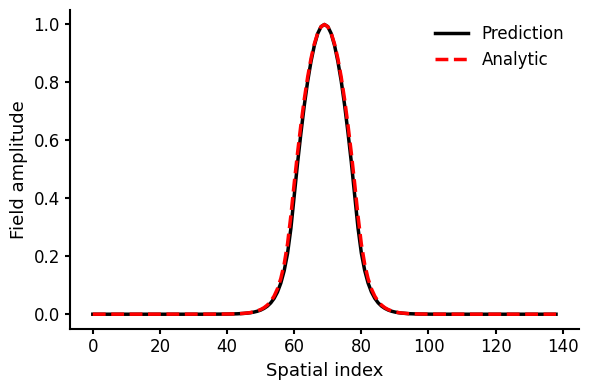

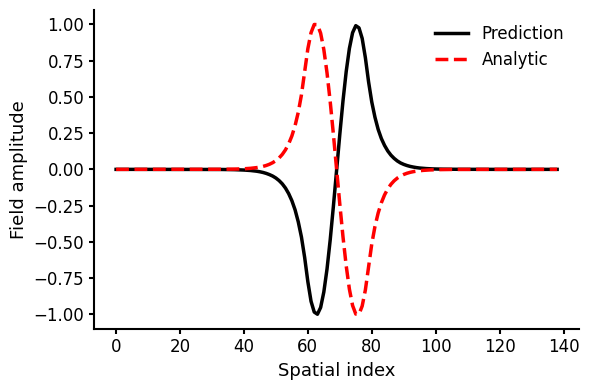

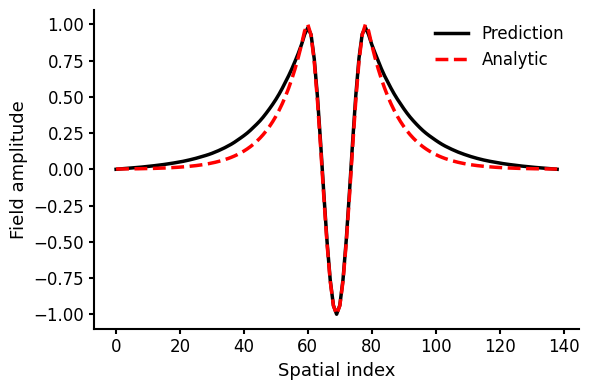

In [20]:
_, x, u = fd_device.evaluate(num_modes)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)
# augmented_x = torch.cat((torch.from_numpy(x)reshape(-1, 1), device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)

predictions = [model_networks[i](torch.from_numpy(evaluation_points).reshape(-1, 1).detach()) for i in range(3)]
prediction_normed = torch.cat(predictions, dim=1)
prediction_normed = prediction_normed  / torch.max(torch.abs(prediction_normed), dim=0, keepdims=True)[0]

utils.compare_against_analytic(reference_device, evaluation_points, prediction_normed.detach().cpu(), plot=True);